# Going to see the effect of Normalization on the model.

In [56]:
import torch
from torch import nn
import matplotlib.pyplot as plt

In [57]:
# Employee Performance Score Prediction

torch.manual_seed(42)
samples = 1000
weights = torch.Tensor([0.5, 0.9, 0.3, 0.4, 0.8]).unsqueeze(1)
bias = 0.4

attendance = torch.randint(60, 101, (samples, 1))          # Percentage # range(60 - 100)
experience = torch.randint(0, 11, (samples, 1))            # Years # range (0 - 10)
current_projects = torch.randint(1, 6, (samples, 1))       # range (1 - 5)
completed_projects = (experience  * 2) + torch.randint(1, 35, (samples, 1)) # range (1 - 34)
weekly_working_hours = torch.randint(30, 51, (samples, 1)) # range (30 - 50)

X = torch.concat((attendance, experience, current_projects, completed_projects, weekly_working_hours), dim=1).float()
X = (X - X.min()) / (X.max() - X.min()) 
noise = torch.randn(samples, 1) * 5  # noise level
y = torch.matmul(X, weights) + bias # + noise if you uncomment this line this current model accuracy will go down because of the current approach of loss function and optimzer we had used # Employee Performance Score
y = (y - y.min()) / (y.max() - y.min()) * 100
X[:10] , y[:10]
# ranges
# Attendance         : 60–100
# Experience         : 0–10
# Current Projects   : 1–5
# Completed Projects : 1–55
# Weekly Hours       : 30–50

(tensor([[0.6000, 0.0900, 0.0200, 0.3600, 0.4500],
         [0.6800, 0.0100, 0.0400, 0.3000, 0.3500],
         [0.9400, 0.0900, 0.0100, 0.3200, 0.4900],
         [0.6800, 0.0100, 0.0300, 0.3000, 0.4900],
         [0.8200, 0.0300, 0.0100, 0.2100, 0.5000],
         [0.7100, 0.0200, 0.0100, 0.1900, 0.4600],
         [0.7100, 0.0000, 0.0300, 0.1400, 0.3900],
         [0.8700, 0.0800, 0.0400, 0.4900, 0.4500],
         [0.7100, 0.0700, 0.0400, 0.4600, 0.4300],
         [0.6900, 0.0500, 0.0400, 0.2900, 0.3900]]),
 tensor([[51.7182],
         [29.3814],
         [83.1615],
         [48.1100],
         [57.3883],
         [39.5189],
         [24.3986],
         [83.3333],
         [63.2302],
         [41.2371]]))

In [58]:
split_ratio = int(0.8 * len(X))

x_train, y_train = X[:split_ratio], y[:split_ratio]
x_test, y_test = X[split_ratio:], y[split_ratio:]

len(x_train), len(y_train), len(x_test), len(y_test)

(800, 800, 200, 200)

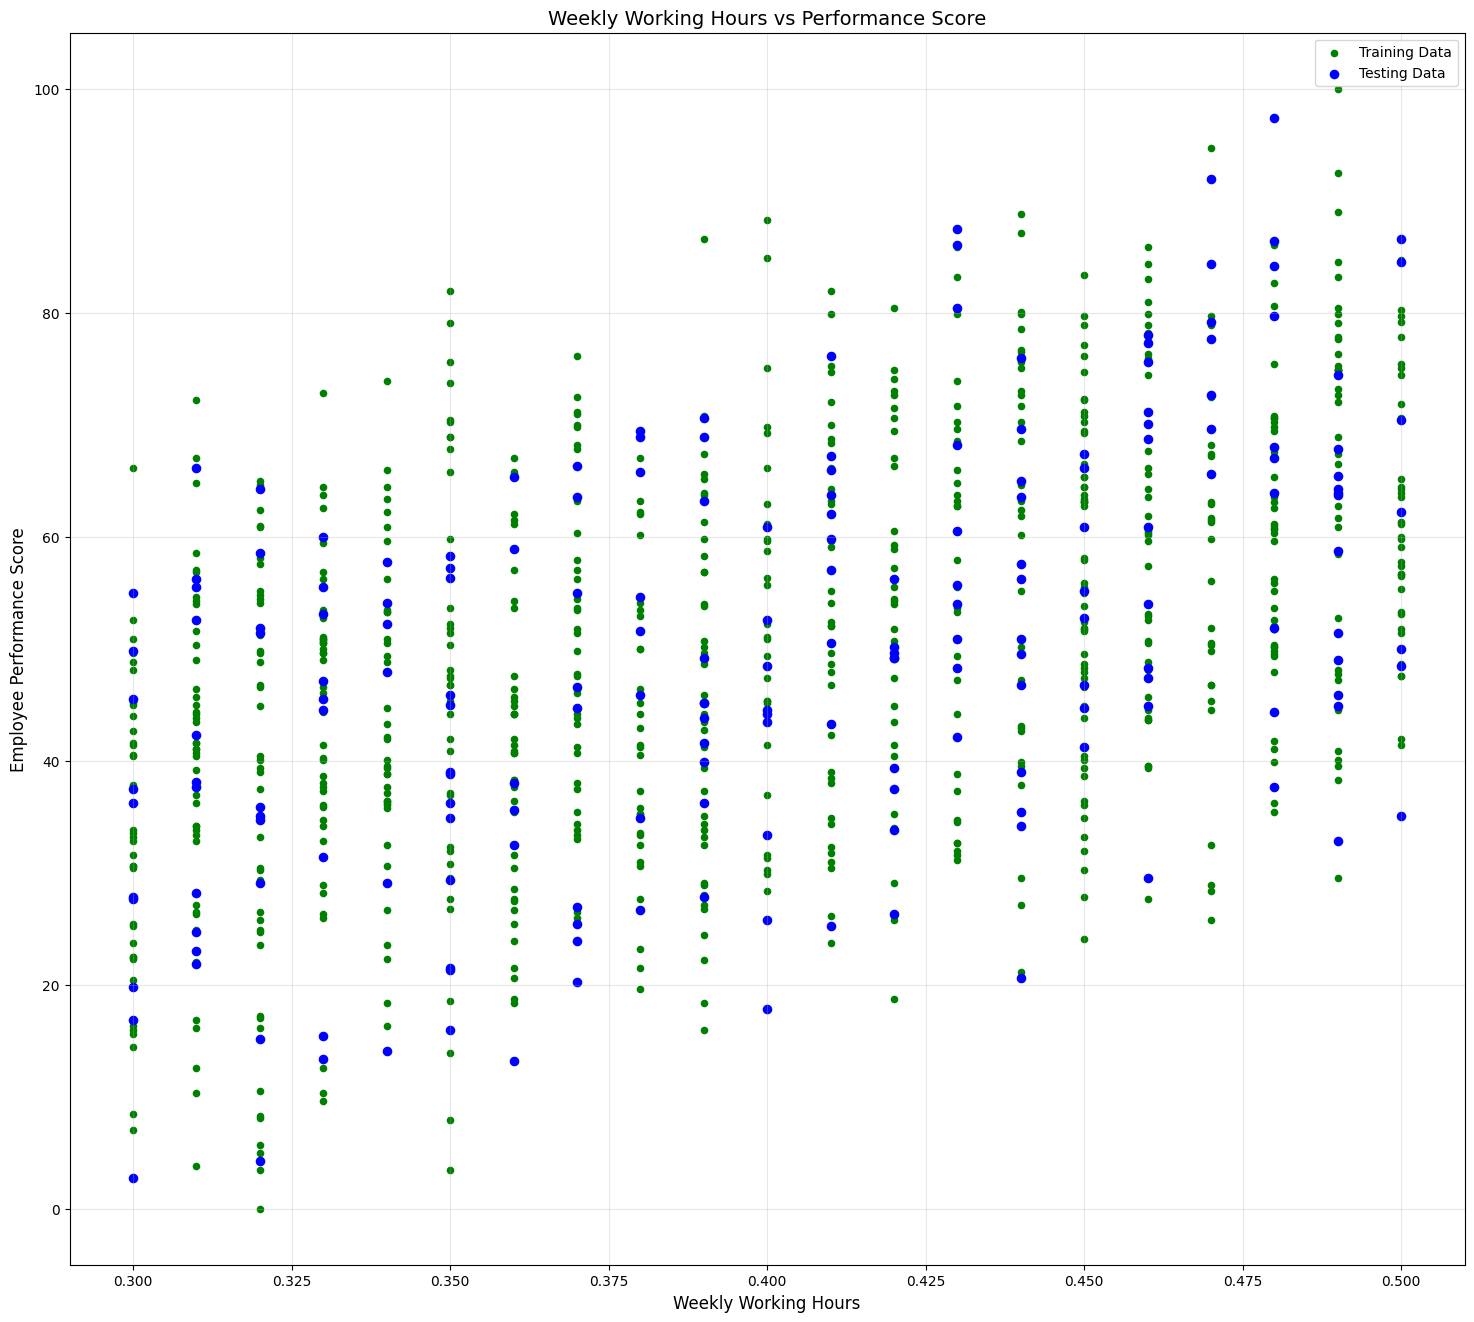

In [59]:
feature_names = [
    "Attendance (%)",
    "Experience (Years)",
    "Current Projects",
    "Completed Projects",
    "Weekly Working Hours"
]

def dataset_intuition(
    feature_index=0,
    x_train=x_train,
    y_train=y_train,
    x_test=x_test,
    y_test=y_test,
    predictions=None
):
    plt.figure(figsize=(18, 16))

    plt.scatter(
        x_train[:, feature_index],
        y_train,
        color="green",
        s=20,
        label="Training Data"
    )

    plt.scatter(
        x_test[:, feature_index],
        y_test,
        color="blue",
        s=35,
        label="Testing Data"
    )

    if predictions is not None:
        plt.scatter(
            x_test[:, feature_index],
            predictions,
            color="red",
            s=20,
            label="Predictions"
        )

    plt.xlabel(feature_names[feature_index], fontsize=12)
    plt.ylabel("Employee Performance Score", fontsize=12)
    plt.title(f"{feature_names[feature_index]} vs Performance Score", fontsize=14)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()
    
dataset_intuition(4)

In [60]:
class PerformanceScorePredictorModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(5,1), requires_grad=True)        
        self.bias = nn.Parameter(torch.rand(1), requires_grad=True)        
        
    def forward(self, X:torch.Tensor):
        return torch.matmul(X, self.weights) + self.bias

In [61]:
torch.manual_seed(42)
model = PerformanceScorePredictorModel()
print(model.state_dict())

OrderedDict({'weights': tensor([[ 0.3367],
        [ 0.1288],
        [ 0.2345],
        [ 0.2303],
        [-1.1229]]), 'bias': tensor([0.8694])})


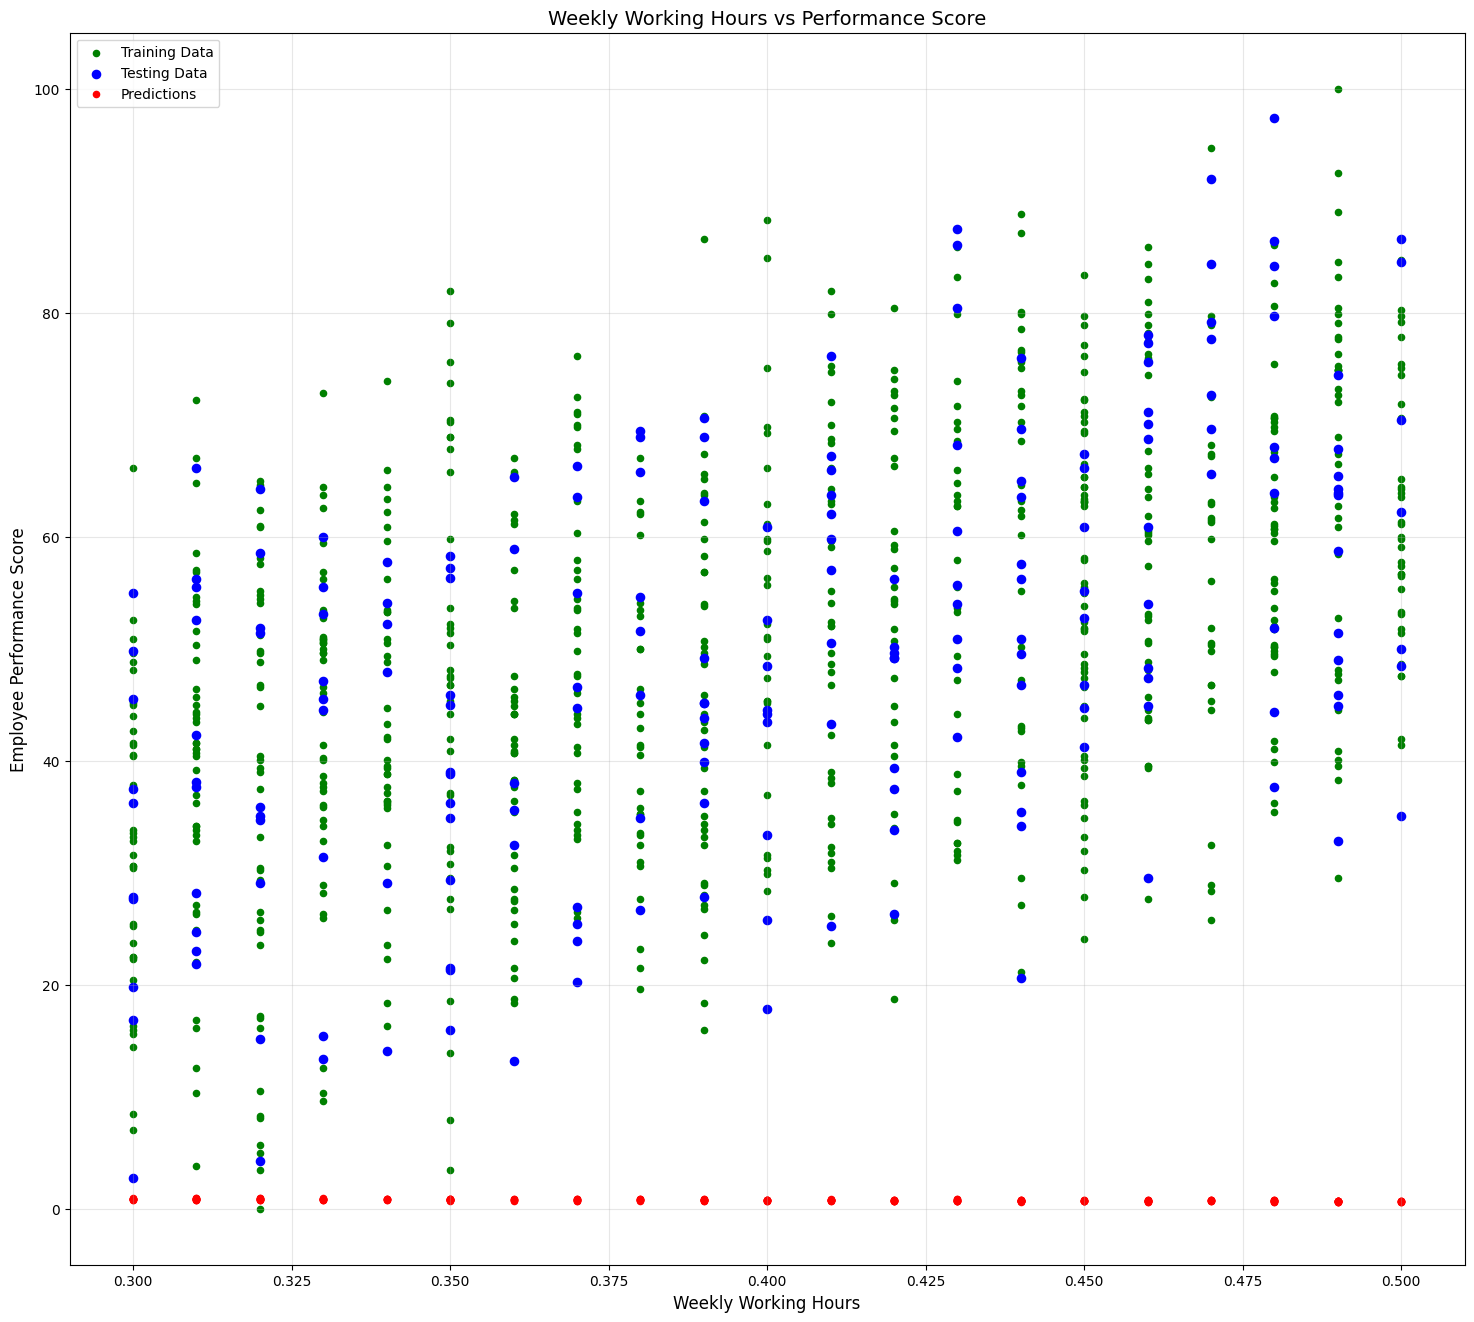

In [62]:
with torch.inference_mode():
    ypred = model(x_test)
ypred
dataset_intuition(feature_index=4,predictions=ypred)

In [ ]:
loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(params=model.parameters(), lr=0.1)

In [64]:
epochs = 1000

for epoch in range(epochs):
    model.train()
    
    model_predictions = model(x_train)
    train_loss = loss_fn(model_predictions,y_train)
    
    optimizer.zero_grad()
    train_loss.backward()
    optimizer.step()
    model.eval()
    
    if epoch % 10 == 0:                        
        print(f"Epoch number: {epoch + 1 } | MAE Train Loss: {train_loss} ")
        
        
    

Epoch number: 1 | MAE Train Loss: 49.255760192871094 
Epoch number: 11 | MAE Train Loss: 47.386085510253906 
Epoch number: 21 | MAE Train Loss: 45.522769927978516 
Epoch number: 31 | MAE Train Loss: 43.68099594116211 
Epoch number: 41 | MAE Train Loss: 41.85344314575195 
Epoch number: 51 | MAE Train Loss: 40.048789978027344 
Epoch number: 61 | MAE Train Loss: 38.26914978027344 
Epoch number: 71 | MAE Train Loss: 36.51319885253906 
Epoch number: 81 | MAE Train Loss: 34.77167510986328 
Epoch number: 91 | MAE Train Loss: 33.044761657714844 
Epoch number: 101 | MAE Train Loss: 31.376419067382812 
Epoch number: 111 | MAE Train Loss: 29.748119354248047 
Epoch number: 121 | MAE Train Loss: 28.169116973876953 
Epoch number: 131 | MAE Train Loss: 26.629995346069336 
Epoch number: 141 | MAE Train Loss: 25.142419815063477 
Epoch number: 151 | MAE Train Loss: 23.740402221679688 
Epoch number: 161 | MAE Train Loss: 22.441537857055664 
Epoch number: 171 | MAE Train Loss: 21.231054306030273 
Epoch nu

OrderedDict({'weights': tensor([[23.1668],
        [ 2.4270],
        [ 1.0081],
        [11.9207],
        [10.4209]]), 'bias': tensor([24.4711])})
Actual weights:  tensor([[0.5000],
        [0.9000],
        [0.3000],
        [0.4000],
        [0.8000]])
Actual bias:  0.4
tensor([[52.0805],
        [52.7696],
        [46.0140],
        [53.9284],
        [49.3103],
        [47.4250],
        [55.7309],
        [53.8226],
        [48.9172],
        [49.8624],
        [57.7661],
        [57.6934],
        [53.0351],
        [48.3053],
        [55.1786],
        [55.7464],
        [48.9262],
        [52.1211],
        [49.9699],
        [52.4010],
        [48.2597],
        [53.2507],
        [46.5040],
        [48.6368],
        [49.8792],
        [53.8354],
        [45.5463],
        [52.3846],
        [56.4821],
        [52.6126],
        [52.6819],
        [50.4869],
        [54.4937],
        [54.8188],
        [49.9926],
        [49.2665],
        [48.9909],
        [46.9937],
   

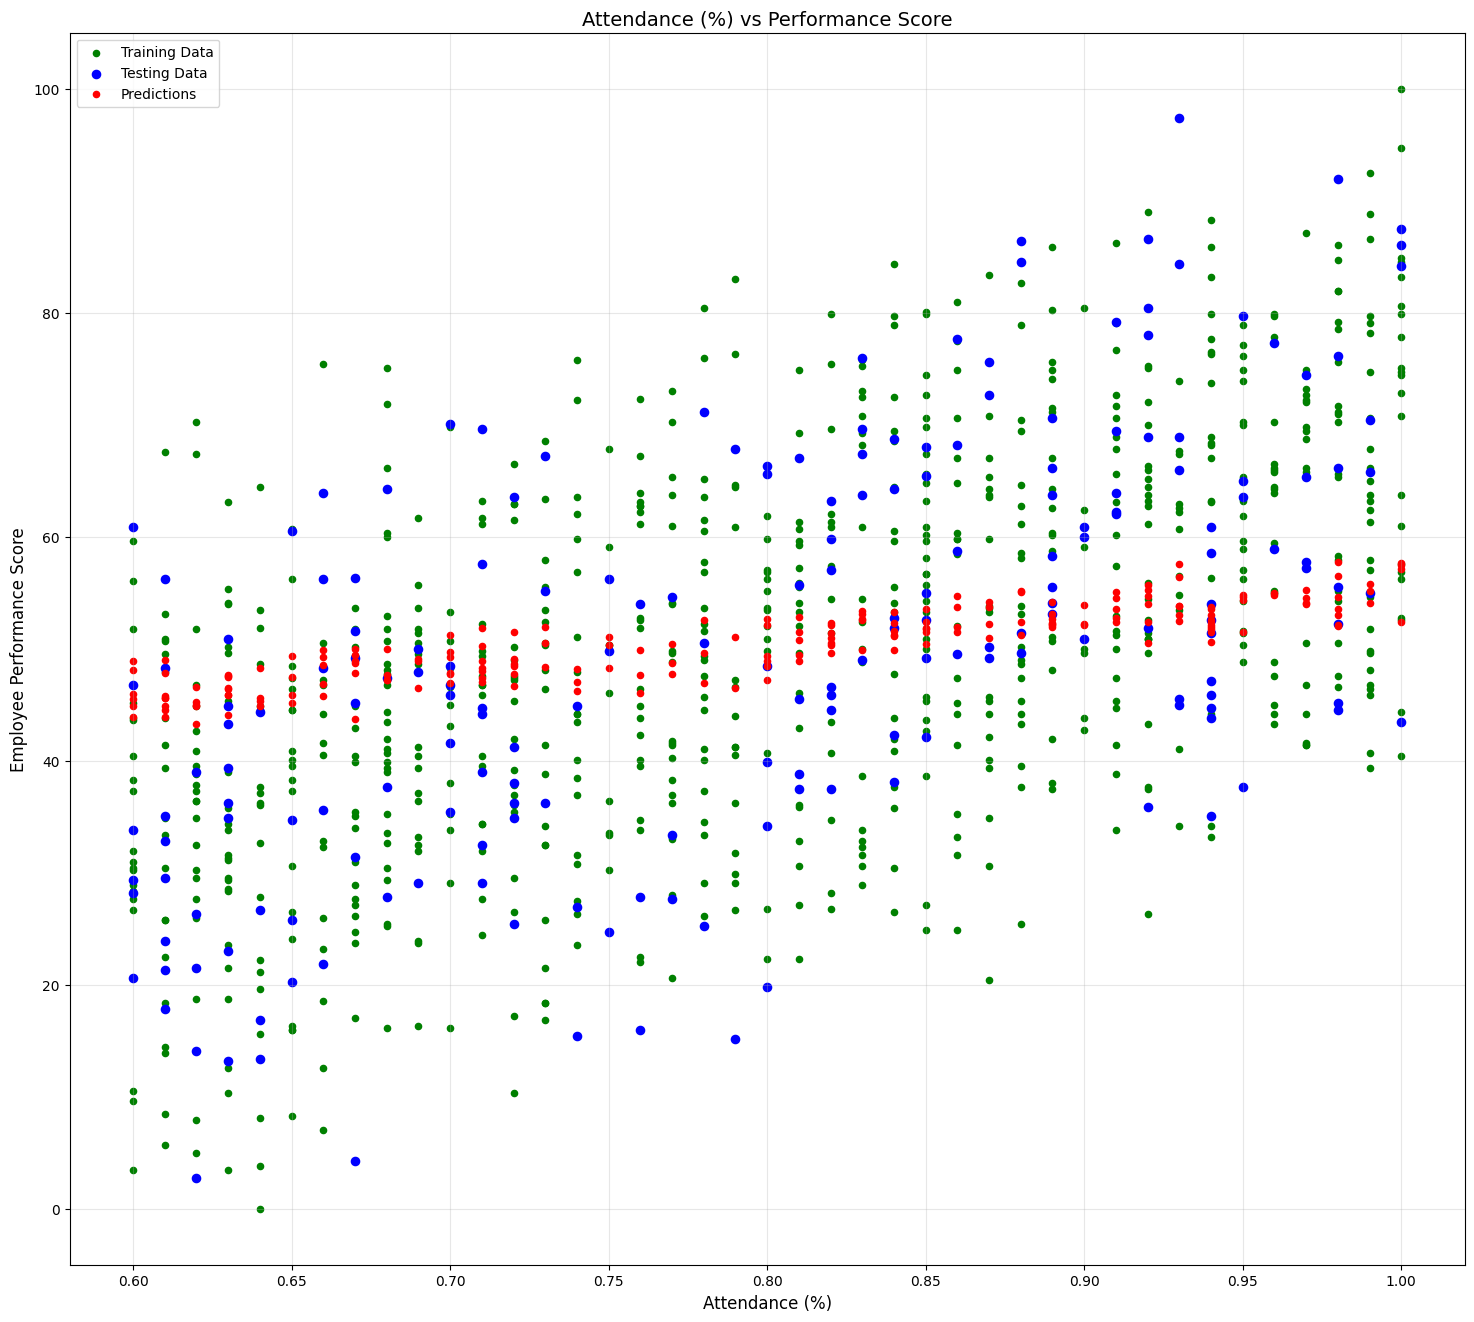

In [65]:
with torch.inference_mode():
    test_pred = model(x_test)
print(model.state_dict())
print(f"Actual weights: " , weights)
print(f"Actual bias: " , bias)
print(test_pred)
dataset_intuition(feature_index=0,predictions=test_pred)